In [1]:
import sys
from pathlib import Path

# Add the project root to Python's import path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import math
import matplotlib.pyplot as plt

from src.root_finding import bisection
from src.differentiation import central_difference
from src.integration import trapezoidal, simpson_one_third, simpson_three_eighth
from src.ode import euler, heun, rk4

print("Convergence analysis environment ready.")

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import sys
from pathlib import Path

# Add the project root to Python's import path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

import math
import matplotlib.pyplot as plt

from src.root_finding import bisection
from src.differentiation import central_difference
from src.integration import trapezoidal, simpson_one_third, simpson_three_eighth
from src.ode import euler, heun, rk4

print("Convergence analysis environment ready.")

Convergence analysis environment ready.


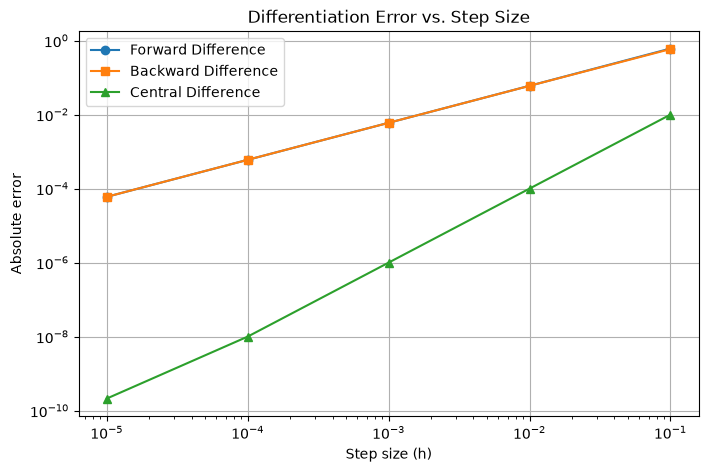

In [2]:
# Differentiation error vs. step size

def f(x):
    return x**3

x = 2
exact = 12

step_sizes = [0.1, 0.01, 0.001, 0.0001, 0.00001]

forward_errors = []
backward_errors = []
central_errors = []

for h in step_sizes:
    forward = (f(x + h) - f(x)) / h
    backward = (f(x) - f(x - h)) / h
    central = (f(x + h) - f(x - h)) / (2 * h)

    forward_errors.append(abs(forward - exact))
    backward_errors.append(abs(backward - exact))
    central_errors.append(abs(central - exact))

plt.figure(figsize=(8, 5))

plt.loglog(step_sizes, forward_errors, marker="o", label="Forward Difference")
plt.loglog(step_sizes, backward_errors, marker="s", label="Backward Difference")
plt.loglog(step_sizes, central_errors, marker="^", label="Central Difference")

plt.xlabel("Step size (h)")
plt.ylabel("Absolute error")
plt.title("Differentiation Error vs. Step Size")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The error decreases as the step size `h` becomes smaller.

- Forward Difference has approximately first-order accuracy: O(h).
- Backward Difference has approximately first-order accuracy: O(h).
- Central Difference has approximately second-order accuracy: O(h²).

Therefore, the central difference method achieves higher accuracy for the same step size in this experiment.

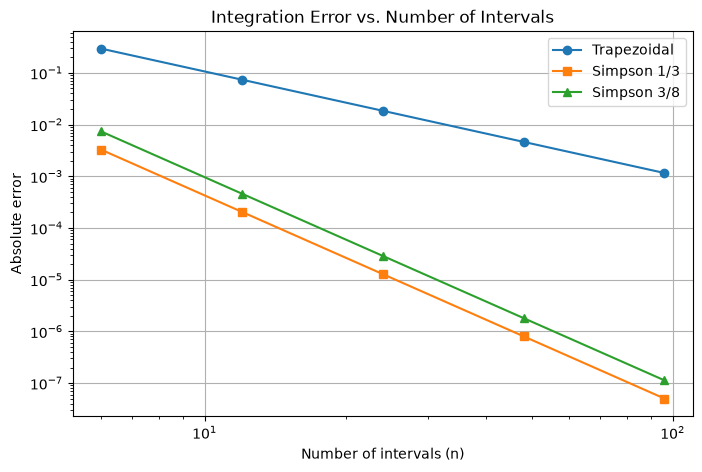

In [4]:
# Integration error vs. number of intervals

def f(x):
    return x**4

exact = 32 / 5

n_values = [6, 12, 24, 48, 96]

trapezoidal_errors = []
simpson_13_errors = []
simpson_38_errors = []

for n in n_values:
    trap = trapezoidal(f, 0, 2, n)
    simpson13 = simpson_one_third(f, 0, 2, n)
    simpson38 = simpson_three_eighth(f, 0, 2, n)

    trapezoidal_errors.append(abs(trap - exact))
    simpson_13_errors.append(abs(simpson13 - exact))
    simpson_38_errors.append(abs(simpson38 - exact))

plt.figure(figsize=(8, 5))

plt.loglog(n_values, trapezoidal_errors, marker="o", label="Trapezoidal")
plt.loglog(n_values, simpson_13_errors, marker="s", label="Simpson 1/3")
plt.loglog(n_values, simpson_38_errors, marker="^", label="Simpson 3/8")

plt.xlabel("Number of intervals (n)")
plt.ylabel("Absolute error")
plt.title("Integration Error vs. Number of Intervals")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The error decreases as the number of intervals increases.

- The Trapezoidal Rule shows approximately second-order convergence: O(h²).
- Simpson's 1/3 Rule shows approximately fourth-order convergence: O(h⁴).
- Simpson's 3/8 Rule shows approximately fourth-order convergence: O(h⁴).

The Simpson methods converge faster than the Trapezoidal Rule and therefore achieve higher accuracy as the step size decreases.

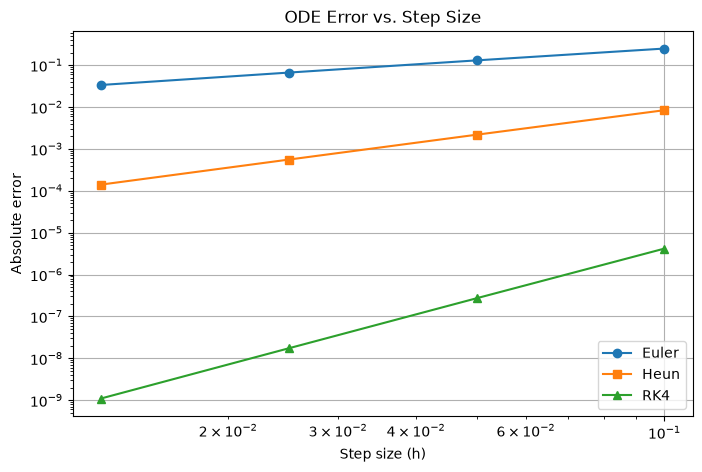

In [5]:
# ODE error vs. step size

def ode_function(x, y):
    return x + y

def exact_solution(x):
    return 2 * math.exp(x) - x - 1

step_sizes = [0.1, 0.05, 0.025, 0.0125]

euler_errors = []
heun_errors = []
rk4_errors = []

for h in step_sizes:
    n = int(1 / h)

    euler_result = euler(ode_function, 0, 1, h, n)
    heun_result = heun(ode_function, 0, 1, h, n)
    rk4_result = rk4(ode_function, 0, 1, h, n)

    exact = exact_solution(1)

    euler_errors.append(abs(euler_result[-1]["y"] - exact))
    heun_errors.append(abs(heun_result[-1]["y"] - exact))
    rk4_errors.append(abs(rk4_result[-1]["y"] - exact))

plt.figure(figsize=(8, 5))

plt.loglog(step_sizes, euler_errors, marker="o", label="Euler")
plt.loglog(step_sizes, heun_errors, marker="s", label="Heun")
plt.loglog(step_sizes, rk4_errors, marker="^", label="RK4")

plt.xlabel("Step size (h)")
plt.ylabel("Absolute error")
plt.title("ODE Error vs. Step Size")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The error decreases as the step size becomes smaller.

- Euler method shows approximately first-order convergence: O(h).
- Heun method shows approximately second-order convergence: O(h²).
- RK4 shows approximately fourth-order convergence: O(h⁴).

RK4 achieves much smaller error for the same step size in this experiment.

In [7]:
# Bisection convergence: error vs. iteration

def f(x):
    return x**3 - x - 2

root, _ = bisection(1, 2, tolerance=1e-12, max_iterations=50)

# Exact root for comparison
exact_root = 1.5213797068

# Calculate error
error = abs(root - exact_root)

print("Approximate root:", root)
print("Absolute error:", error)

Approximate root: 1.5213797068045096
Absolute error: 4.509725926027386e-12


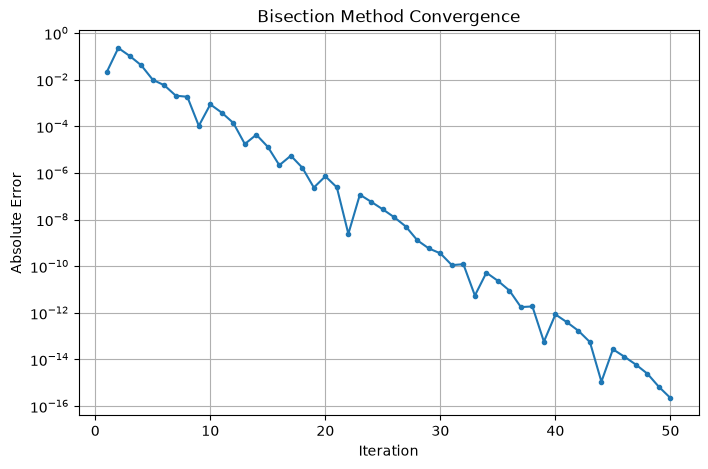

Approximate root: 1.5213797068045674
Final absolute error: 2.220446049250313e-16


In [8]:
# Bisection convergence: error vs. iteration

def f(x):
    return x**3 - x - 2

a, b = 1.0, 2.0
exact_root = 1.5213797068045676

iterations = []
errors = []

for i in range(1, 51):
    midpoint = (a + b) / 2
    error = abs(midpoint - exact_root)

    iterations.append(i)
    errors.append(error)

    if f(a) * f(midpoint) < 0:
        b = midpoint
    else:
        a = midpoint

plt.figure(figsize=(8, 5))

plt.semilogy(iterations, errors, marker="o", markersize=3)

plt.xlabel("Iteration")
plt.ylabel("Absolute Error")
plt.title("Bisection Method Convergence")
plt.grid(True)

plt.show()

print("Approximate root:", midpoint)
print("Final absolute error:", errors[-1])

### Observation

The absolute error decreases as the number of bisection iterations increases.

Each iteration approximately halves the bracketing interval. Therefore, the Bisection Method has reliable but relatively slow (linear) convergence.

# Numerical Methods: Error and Convergence Analysis

This notebook studies the accuracy and convergence behavior of selected numerical methods implemented in this project.

The experiments cover:

- Numerical differentiation
- Numerical integration
- Ordinary differential equations
- Root finding

The goal is to compare theoretical error orders with observed numerical behavior.